# 🏦 Bank Customer Churn Prediction

## End-to-End Machine Learning Project

**Objective:** Build a machine learning classification system that predicts whether a bank customer is likely to leave the bank.

**Target variable:** `Exited`
- `0` = Customer stayed
- `1` = Customer exited

This notebook covers the complete workflow required for the academy project: data loading, cleaning, EDA, preprocessing, model training, evaluation, model comparison, and saving the final model for the Streamlit application.

## 1. Import Libraries

We import the main Python libraries needed for data analysis, visualization, preprocessing, machine learning, evaluation, and model serialization.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

# Model serialization
import joblib

# Consistent visual appearance
sns.set_theme(style="whitegrid")


## 2. Load the Dataset

The CSV file is expected to be in the same folder as this notebook. If you are using Google Colab, upload `Churn_Modelling.csv` into the Colab session first.

In [2]:
# Load the customer churn dataset
df = pd.read_csv("Churn_Modelling.csv")

# Display the first five rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Understand the Dataset

Before changing anything, we inspect its shape, columns, data types, and summary statistics.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (10000, 14)

Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:


RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


Summary statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 4. Check Missing Values and Duplicates

Missing values and duplicate records can cause problems during analysis and modeling, so we check them before preprocessing.

In [4]:
print("Missing values per column:")
display(df.isnull().sum())

print("Number of duplicate rows:", df.duplicated().sum())

Missing values per column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Number of duplicate rows: 0


## 5. Data Cleaning

`RowNumber`, `CustomerId`, and `Surname` identify records/customers but do not provide useful general predictive information for this project. We remove them before modeling.

In [5]:
# Remove identifier columns that are not useful predictive features
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print("Shape after removing identifier columns:", df.shape)
df.head()

Shape after removing identifier columns: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 6. Define the Project Goal

The goal is to predict customer churn. The column `Exited` is therefore our target. All other remaining columns are candidate input features.

In [6]:
# Check the target distribution
print(df["Exited"].value_counts())
print("\nTarget proportions:")
display(df["Exited"].value_counts(normalize=True).mul(100).round(2))

Exited
0    7963
1    2037
Name: count, dtype: int64

Target proportions:


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

## 7. Exploratory Data Analysis (EDA)

EDA helps us understand patterns in customer churn before building the model. We focus on questions that are relevant to the banking business.

### 7.1 Overall Customer Churn

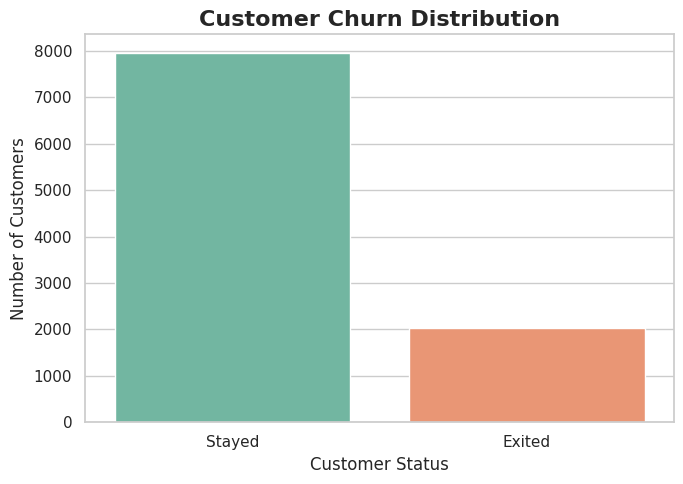

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Exited", data=df, hue="Exited", palette="Set2", legend=False)
plt.title("Customer Churn Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Customer Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.tight_layout()
plt.show()

### 7.2 Churn by Geography

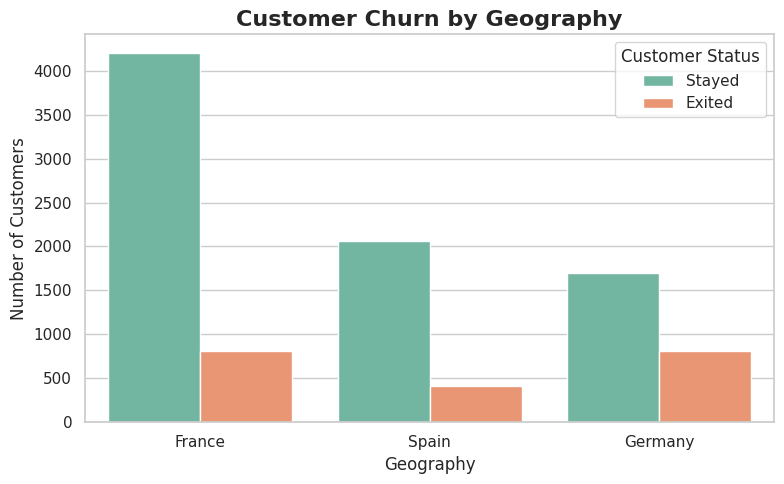

Churn rate by geography (%):


Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Geography", hue="Exited", data=df, palette="Set2")
plt.title("Customer Churn by Geography", fontsize=16, fontweight="bold")
plt.xlabel("Geography", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Customer Status", labels=["Stayed", "Exited"])
plt.tight_layout()
plt.show()

print("Churn rate by geography (%):")
display((df.groupby("Geography")["Exited"].mean() * 100).round(2))

### 7.3 Age and Churn

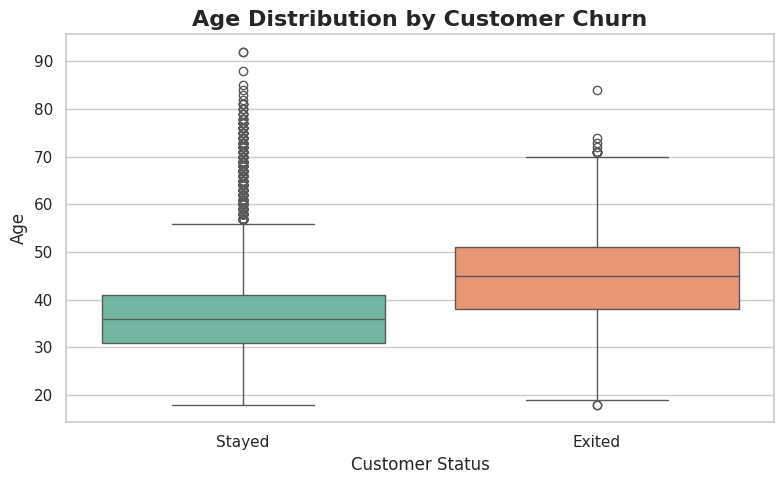

Average age by churn status:


Exited
0    37.41
1    44.84
Name: Age, dtype: float64

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Exited", y="Age", data=df, hue="Exited", palette="Set2", legend=False)
plt.title("Age Distribution by Customer Churn", fontsize=16, fontweight="bold")
plt.xlabel("Customer Status", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.tight_layout()
plt.show()

print("Average age by churn status:")
display(df.groupby("Exited")["Age"].mean().round(2))

### 7.4 Active Membership and Churn

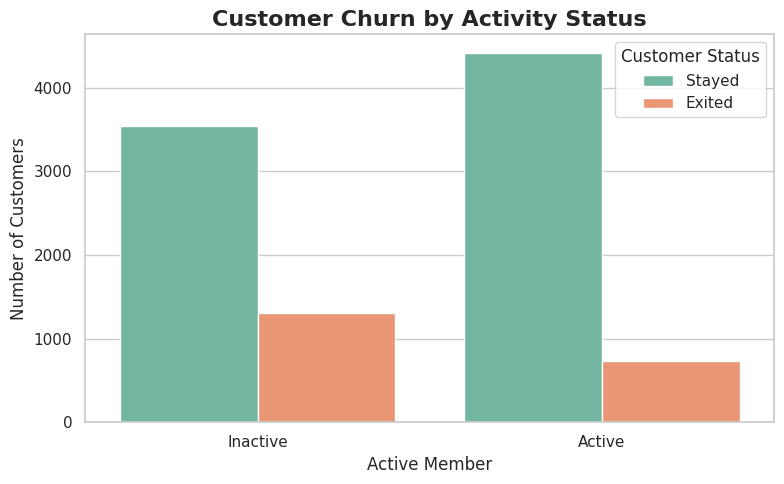

Churn rate by activity status (%):


IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x="IsActiveMember", hue="Exited", data=df, palette="Set2")
plt.title("Customer Churn by Activity Status", fontsize=16, fontweight="bold")
plt.xlabel("Active Member", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks([0, 1], ["Inactive", "Active"])
plt.legend(title="Customer Status", labels=["Stayed", "Exited"])
plt.tight_layout()
plt.show()

print("Churn rate by activity status (%):")
display((df.groupby("IsActiveMember")["Exited"].mean() * 100).round(2))

### 7.5 Number of Products and Churn

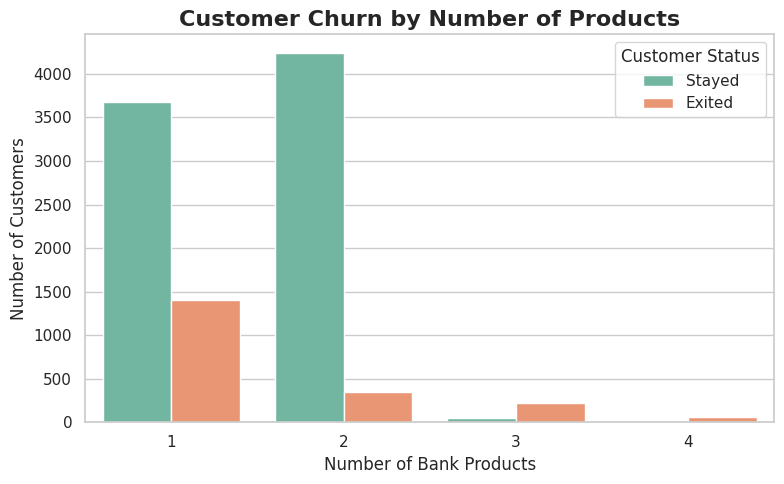

Churn rate by number of products (%):


NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x="NumOfProducts", hue="Exited", data=df, palette="Set2")
plt.title("Customer Churn by Number of Products", fontsize=16, fontweight="bold")
plt.xlabel("Number of Bank Products", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Customer Status", labels=["Stayed", "Exited"])
plt.tight_layout()
plt.show()

print("Churn rate by number of products (%):")
display((df.groupby("NumOfProducts")["Exited"].mean() * 100).round(2))

## 8. Separate Features and Target

`X` contains the information used by the model. `y` contains the answer we want the model to predict.

In [12]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


## 9. Train/Test Split

We reserve 20% of the data as unseen test data. The model learns from the training set and is evaluated on the test set.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


## 10. Preprocessing

The model cannot directly use text categories such as `France` or `Male`. We use one-hot encoding for categorical columns. Numerical columns are standardized so their scales are comparable.

In [14]:
categorical_features = ["Geography", "Gender"]

numerical_features = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember",
    "EstimatedSalary"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing configuration created successfully.")

Preprocessing configuration created successfully.


## 11. Model 1 — Logistic Regression

Logistic Regression is a strong baseline classification algorithm. It predicts the probability of a customer belonging to the churn class.

In [15]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Train the complete preprocessing + model pipeline
logistic_model.fit(X_train, y_train)

# Predict the unseen test customers
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


### 11.1 Logistic Regression Evaluation

In [16]:
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, zero_division=0)
logistic_f1 = f1_score(y_test, logistic_pred, zero_division=0)
logistic_auc = roc_auc_score(y_test, logistic_prob)

print(f"Accuracy:  {logistic_accuracy:.4f} ({logistic_accuracy:.2%})")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, target_names=["Stayed", "Exited"], zero_division=0))

Accuracy:  0.8080 (80.80%)
Precision: 0.5891
Recall:    0.1867
F1-Score:  0.2836
ROC-AUC:   0.7748

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
      Exited       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### 11.2 Logistic Regression Confusion Matrix

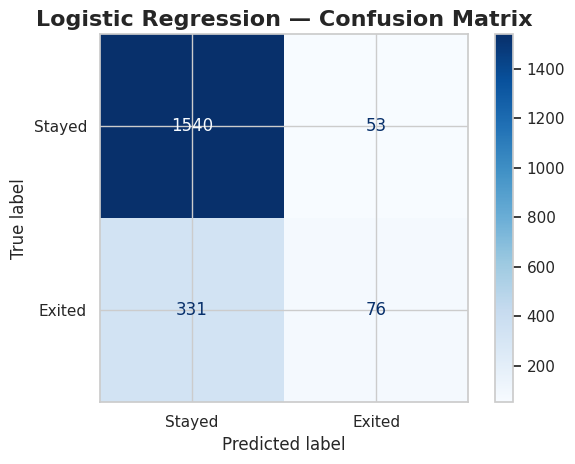

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=["Stayed", "Exited"],
    cmap="Blues"
)
plt.title("Logistic Regression — Confusion Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 12. ROC-AUC

ROC-AUC measures how well the model separates customers who churn from customers who stay. A value closer to 1 indicates stronger discrimination.

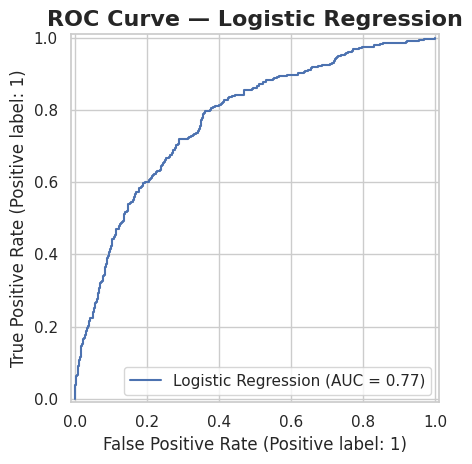

Logistic Regression ROC-AUC: 0.7748


In [18]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_prob,
    name="Logistic Regression"
)
plt.title("ROC Curve — Logistic Regression", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Logistic Regression ROC-AUC: {logistic_auc:.4f}")

## 13. Model 2 — Random Forest

Random Forest combines many decision trees. It can capture nonlinear relationships and interactions that a simple linear model may miss.

In [19]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

# Train the Random Forest pipeline
random_forest_model.fit(X_train, y_train)

# Predict the unseen test customers
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


### 13.1 Random Forest Evaluation

In [20]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy:  {rf_accuracy:.4f} ({rf_accuracy:.2%})")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=["Stayed", "Exited"], zero_division=0))

Accuracy:  0.8590 (85.90%)
Precision: 0.7660
Recall:    0.4423
F1-Score:  0.5607
ROC-AUC:   0.8532

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
      Exited       0.77      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



### 13.2 Random Forest Confusion Matrix

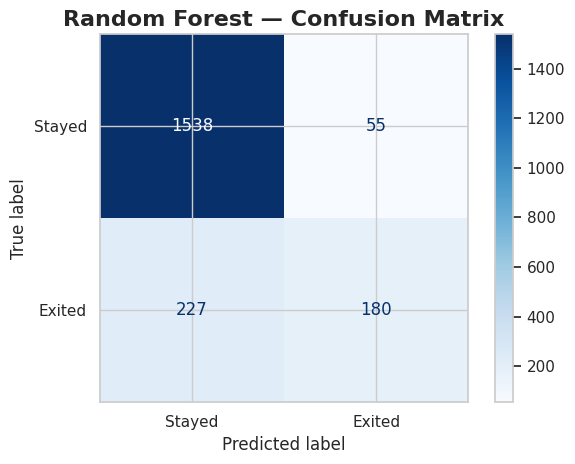

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Stayed", "Exited"],
    cmap="Blues"
)
plt.title("Random Forest — Confusion Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Compare Both Models

In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1-Score": [logistic_f1, rf_f1],
    "ROC-AUC": [logistic_auc, rf_auc]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.808,0.5891,0.1867,0.2836,0.7748
1,Random Forest,0.859,0.7660,0.4423,0.5607,0.8532


### 14.1 Visual Model Comparison

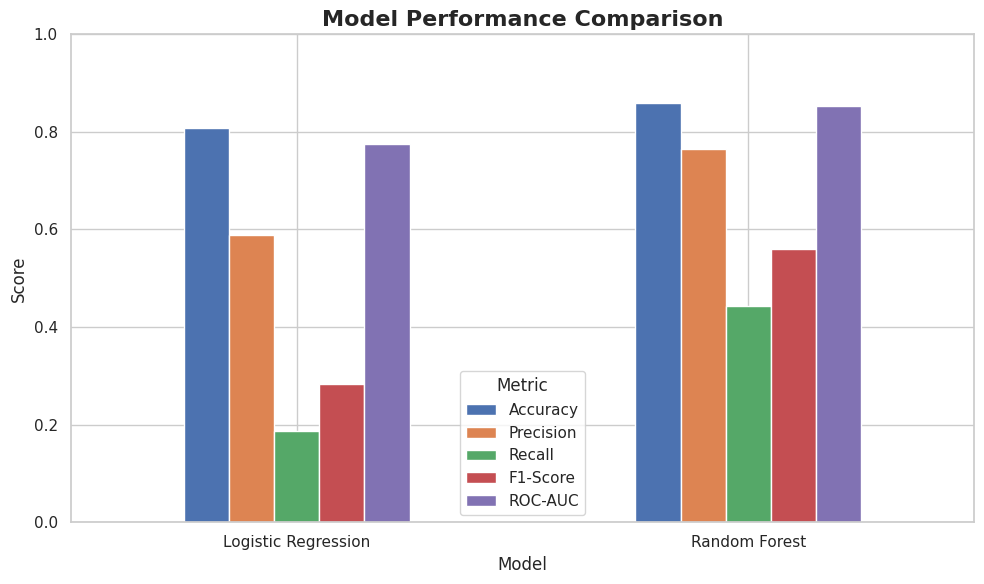

In [23]:
comparison_plot = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]
comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison", fontsize=16, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 15. Select the Best Model

For churn prediction, accuracy alone is not enough because the classes are imbalanced. We use F1-score as the primary selection metric and ROC-AUC as a secondary metric.

In [24]:
best_model_name = (
    results.sort_values(["F1-Score", "ROC-AUC"], ascending=False)
    .iloc[0]["Model"]
)

best_model = (
    random_forest_model
    if best_model_name == "Random Forest"
    else logistic_model
)

print(f"Selected model: {best_model_name}")


Selected model: Random Forest


## 16. Save the Final Model

We serialize the complete pipeline with Joblib. This file can later be loaded by Streamlit without retraining the model.

In [25]:
MODEL_FILE = "churn_model.joblib"
joblib.dump(best_model, MODEL_FILE)
print(f"Model saved successfully as: {MODEL_FILE}")

Model saved successfully as: churn_model.joblib


## 17. Verify the Saved Model

We load the serialized model back and make one test prediction. This confirms that the saved file is usable.

In [26]:
loaded_model = joblib.load(MODEL_FILE)

sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0, 1]

print("Prediction:", "Exited" if prediction == 1 else "Stayed")
print(f"Churn probability: {probability:.2%}")

Prediction: Stayed
Churn probability: 6.33%


## 18. Final Project Summary

The complete machine learning workflow is now finished. The saved `churn_model.joblib` contains both preprocessing and the selected trained model, making it ready to be connected to the Streamlit application.

In [27]:
print("PROJECT COMPLETE")
print("=" * 60)
print(f"Dataset: {len(df):,} customers")
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"Selected model: {best_model_name}")
print(f"Accuracy: {results.loc[results['Model'] == best_model_name, 'Accuracy'].iloc[0]:.2%}")
print(f"F1-Score: {results.loc[results['Model'] == best_model_name, 'F1-Score'].iloc[0]:.4f}")
print(f"ROC-AUC: {results.loc[results['Model'] == best_model_name, 'ROC-AUC'].iloc[0]:.4f}")
print("Model file: churn_model.joblib")

PROJECT COMPLETE
Dataset: 10,000 customers
Training rows: 8,000
Testing rows: 2,000
Selected model: Random Forest
Accuracy: 85.90%
F1-Score: 0.5607
ROC-AUC: 0.8532
Model file: churn_model.joblib
